In [1]:
%%time
%pip install -q numpy pandas matplotlib seaborn scikit-learn gensim portalocker>=2.0.0
%pip install torchdata==0.7.1
%pip install torch==2.2.2+cpu torchtext==0.17.2+cpu \
    --index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 93.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.8/186.8 MB 96.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 126.7 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0
    Uninstalling torch-2.6.0:
      Successfully uninstalled torch-2.6.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which 

In [2]:
#removes utils.py if exists
import os
if os.path.exists("utils.py"):
    os.remove("utils.py")
    print("utils.py is removed")
else:
    print("utils.py is not found")

utils.py is not found


In [12]:
print("Current directory:", os.getcwd())
print("\nFiles in current directory:", os.listdir())
import sys
sys.path.insert(0, '/mnt/custom-file-systems/s3/shared')


Current directory: /mnt/custom-file-systems/s3/shared

Files in current directory: ['.libs.json', '.~Integrating Word2Vec Part2.ipynb', '2.Building a Language Model Using Histogram N-Gram Analysis.ipynb', '3.Building and Training a Feedforward Neural Network for Language Modeling.ipynb', '4.Integrating Word2Vec Part1.ipynb', '=2.0.0', 'utils.py', '.ipynb_checkpoints', '.temp_sagemaker_unified_studio_debugging_info', '1.Classifying Document.ipynb', '2gram.pth', '4gram.pth', '8gram.pth', 'Integrating Word2Vec Part2.ipynb', 'my_model.pth']


In [13]:
%%writefile utils.py
import numpy as np

def find_similar_words(target_word, embedding_dict, top_k=2):
    if target_word not in embedding_dict:
        return f"Word {target_word} not found in embeddings"
    target_vector = embedding_dict[target_word]
    similarities = {}
    for word, vector in embedding_dict.items():
        if word == target_word:
            continue
        similarity = np.dot(target_vector, vector) / (np.linalg.norm(target_vector) * np.linalg.norm(vector))
        similarities[word] = similarity
    sorted_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return [word for word, _ in sorted_words[:top_k]]

Overwriting utils.py


In [15]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location(
    "utils", 
    "/mnt/custom-file-systems/s3/shared/utils.py"
)
utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(utils)

find_similar_words = utils.find_similar_words
print("Import successful!")

Import successful!


In [17]:
%%capture
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from collections import defaultdict
import torch
import torch.nn as nn 
from torchtext.vocab import GloVe, vocab
from torchtext.datasets import AG_NEWS
train_iter_ag_news = AG_NEWS(split = "train")
from torch.utils.data.dataset import random_split
from torchtext.data.functional import to_map_style_dataset
from torchtext.data.utils import get_tokenizer 
from torch.utils.data import DataLoader
from tqdm import tqdm 

# Replacing "from utils import find_similar_words" with direct file loader
import importlib.util
spec = importlib.util.spec_from_file_location(
    "utils",
    "/mnt/custom-file-systems/s3/shared/utils.py"
)
utils_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(utils_module)
find_similar_words = utils_module.find_similar_words

%matplotlib inline

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [36]:
device = torch.device ("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [19]:
sentences = [["I", "like", "to", "eat", "pizza"],
             ["Pizza", "is", "my", "favorite", "food"],
             ["I", "enjoy", "eating", "pasta"]]
sentences = [[word.lower() for word in sentence] for sentence in sentences]

In [20]:
from gensim.models import Word2Vec

#Create an instance of Word2Vec model 
w2v_model = Word2Vec(sentences, vector_size = 100, window = 3, min_count = 1, workers =4)

In [21]:
#Build vocab using the training data
w2v_model.build_vocab(sentences, progress_per = 10000)

In [22]:
#Train the model on your training data
w2v_model.train(sentences, total_examples = w2v_model.corpus_count, epochs = 30, report_delay = 1.0)

(55, 420)

In [23]:
#Finding similar words
similar_words = w2v_model.wv.most_similar("pizza")
print("Similar words to 'pizza':", similar_words)

#Calculating word similarity
similarity = w2v_model.wv.similarity("pizza", "pasta")
print("Similarity between 'pizza' and 'pasta':", similarity)

Similar words to 'pizza': [('to', 0.17027318477630615), ('is', 0.13898281753063202), ('my', 0.035433292388916016), ('like', 0.004519706126302481), ('pasta', -0.005902310833334923), ('i', -0.027743982151150703), ('favorite', -0.028113720938563347), ('eat', -0.044309474527835846), ('food', -0.0687345638871193), ('enjoy', -0.1732126623392105)]
Similarity between 'pizza' and 'pasta': -0.0059023127


In [37]:
word_vectors = w2v_model.wv
word_to_index = {word: index for index, word in enumerate(word_vectors.index_to_key)}
embedding_dim = w2v_model.vector_size
embedding = torch.nn.Embedding(len(word_vectors.index_to_key), embedding_dim)
# SAFE loading (no NumPy → Torch conversion)
embedding.weight.data = torch.tensor(
    word_vectors.vectors.tolist(),
    dtype=torch.float32
)
#Example usage 
word = "pizza"
word_index = word_to_index[word]
word_embedding = embedding(torch.LongTensor([word_index]))
print(f"Word: {word}, Embedding shape: {word_embedding.shape}")

Word: pizza, Embedding shape: torch.Size([1, 100])


In [38]:
from torchtext.vocab import GloVe,vocab
# Build vocab from glove_vectors
# vocab(ordered_dict: Dict, min_freq: int = 1, specials: Optional[List[str]] = None)
glove_vectors_6B = GloVe(name ='6B')
vocab = vocab(glove_vectors_6B.stoi, 0,specials=('<unk>', '<pad>'))
vocab.set_default_index(vocab["<unk>"])

In [39]:
vocab(["<unk>","Hello","hello"])

[0, 0, 13077]

In [40]:
#Define tokenizer 
tokenizer = get_tokenizer("basic_english")

In [41]:
#split the dataset into training and testing iterators
train_iter, test_iter = AG_NEWS()
# Convert the training and testing iterators to map-style datasets.
train_dataset = to_map_style_dataset(train_iter)
test_dataset = to_map_style_dataset(test_iter)
# Determine the number of samples to be used for training and validation (5% for validation).
num_train = int(len(train_dataset) * 0.85)
# Randomly split the training dat aset into training and validation datasets using `random_split`.
# The training dataset will contain 95% of the samples, and the validation dataset will contain the remaining 5%.
split_train_, split_valid_ = random_split(train_dataset, [num_train, len(train_dataset) - num_train])

In [42]:
# define class labels
ag_news_label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tec"}
'''ag_news_label[y]'''
num_class = len(set([label for(label, text) in train_iter]))

In [43]:
#Collate data in batches 
def text_pipeline(x):
    x = x.lower()
    return vocab(tokenizer(x))
def label_pipeline(x):
    return int(x) -1 
# create label, text and offset for each batch of data
# text is the concatenated text for all text data in the batch
# you need to have the offsets(the end of text index) for later when you separate texts and predict their label
def collate_batch(batch): 
    label_list, text_list, offsets = [], [], [0]
    for _label , _text in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype = torch.int64)
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))
    label_list = torch.tensor(label_list, dtype = torch.int64)
    offsets = torch.tensor(offsets).cumsum(dim = 0)
    text_list = torch.cat(text_list)
    return label_list.to(device), text_list.to(device), offsets.to(device)
    
        

In [44]:
#Creating dataloader to train, validate and test 
BATCH_SIZE = 64 
train_dataloader = DataLoader(
    split_train_, batch_size = BATCH_SIZE, shuffle = True, collate_fn = collate_batch
    
)
valid_dataloader = DataLoader(
    split_valid_, batch_size = BATCH_SIZE, shuffle = True, collate_fn = collate_batch
)
test_dataloader = DataLoader(
    test_dataset, batch_size = BATCH_SIZE, shuffle = True , collate_fn = collate_batch
)


In [45]:
label, text, offsets = next(iter(train_dataloader))
print(label, text, offsets)
label.shape, text.shape, offsets.shape

tensor([1, 2, 3, 3, 2, 3, 2, 1, 0, 0, 2, 2, 0, 1, 3, 3, 0, 0, 2, 1, 0, 1, 1, 3,
        1, 3, 0, 2, 0, 1, 3, 0, 3, 1, 1, 3, 0, 2, 2, 3, 2, 2, 1, 1, 1, 1, 2, 0,
        0, 0, 1, 1, 3, 2, 2, 3, 2, 3, 3, 2, 3, 2, 1, 2]) tensor([19545,  2264, 38139,  ...,  1806,    18,     4]) tensor([   0,   27,   73,  162,  206,  305,  337,  386,  440,  466,  508,  531,
         575,  618,  657,  682,  721,  767,  817,  850,  881,  922,  963, 1005,
        1052, 1093, 1130, 1208, 1245, 1287, 1317, 1450, 1483, 1520, 1557, 1609,
        1655, 1699, 1733, 1796, 1845, 1892, 1936, 1980, 2010, 2093, 2133, 2165,
        2198, 2251, 2335, 2369, 2410, 2449, 2498, 2540, 2587, 2626, 2671, 2748,
        2794, 2849, 2881, 2915, 2946])


(torch.Size([64]), torch.Size([2946]), torch.Size([65]))

In [46]:
class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class):
        super(TextClassificationModel, self).__init__()
        self.embedding = torch.nn.Embedding.from_pretrained(glove_vectors_6B.vectors,freeze=True)
        self.fc = nn.Linear(embed_dim, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, text,offsets):
        embedded = self.embedding(text)
        # you get the average of word embeddings in the text
        means = []
        for i in range(1,len(offsets)):
            #this is like eme
          text_tmp = embedded[offsets[i-1]:offsets[i]]
          means.append(text_tmp.mean(0))

        return self.fc(torch.stack(means))

In [47]:
def evaluate(dataloader):
    model.eval()
    total_acc, total_count= 0, 0

    with torch.no_grad():
        for idx, (label, text, offsets) in enumerate(dataloader):
            predicted_label = model(text,offsets)

            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc / total_count

In [48]:
# Define hyperparameters
vocab_size=len(vocab)
embedding_dim = 300
# Initialize the model
model = TextClassificationModel(vocab_size, embedding_dim, num_class).to(device)

In [49]:
evaluate(test_dataloader)

0.25276315789473686

In [50]:
def train_TextClassification(model,dataloader,criterion,optimizer,epochs=10):
    
    cum_loss_list=[]
    acc_epoch=[]
    acc_old=0

    for epoch in tqdm(range(1, EPOCHS + 1)):
        model.train()
        cum_loss=0
        for idx, (label, text, offsets) in enumerate(train_dataloader):
            means = []
            optimizer.zero_grad()
            

            predicted_label = model(text, offsets)
            
            loss = criterion(predicted_label, label)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            cum_loss+=loss.item()

        cum_loss_list.append(cum_loss/len(train_dataloader))
        accu_val = evaluate(valid_dataloader)
        acc_epoch.append(accu_val)

        if accu_val > acc_old:
          acc_old= accu_val
          torch.save(model.state_dict(), 'my_model.pth')
            
    return model,cum_loss_list,acc_epoch


In [51]:
# Define hyperparameters
LR=0.1
EPOCHS = 10


criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)

model,cum_loss_list,acc_epoch  = train_TextClassification(model,train_dataloader,criterion,optimizer,EPOCHS)

100%|██████████| 10/10 [03:04<00:00, 18.42s/it]


In [52]:
import matplotlib.pyplot as plt
def plot(COST,ACC):
    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoch', color=color)
    ax1.set_ylabel('total loss', color=color)
    ax1.tick_params(axis='y', color=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  # you already handled the x-label with ax1
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped

    plt.show()

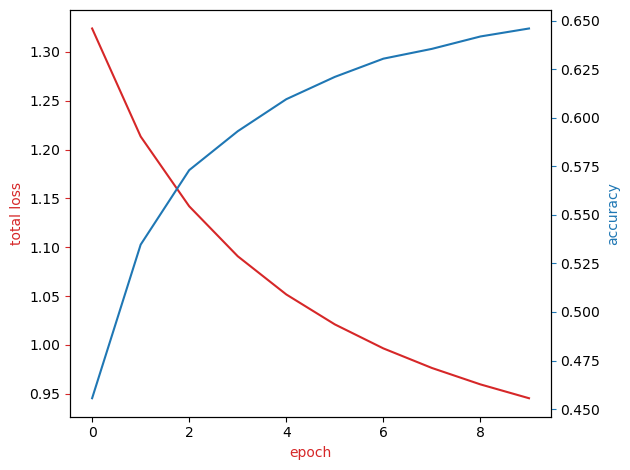

In [53]:
plot(cum_loss_list,acc_epoch)

In [54]:
evaluate(test_dataloader)

0.6473684210526316